# IX. returns.csv — Hoàn trả


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
ROOT_DIR = os.path.dirname(ROOT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

IMAGES_DIR = os.path.join(ROOT_DIR, 'outputs', 'images')
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)

def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

returns_df['return_quantity'] = pd.to_numeric(returns_df['return_quantity'], errors='coerce')
returns_df['refund_amount'] = pd.to_numeric(returns_df['refund_amount'], errors='coerce')
returns_df['refund_amount_log1p'] = np.log1p(returns_df['refund_amount'])

weekday_map = {
    'Monday': 'Thứ 2',
    'Tuesday': 'Thứ 3',
    'Wednesday': 'Thứ 4',
    'Thursday': 'Thứ 5',
    'Friday': 'Thứ 6',
    'Saturday': 'Thứ 7',
    'Sunday': 'Chủ nhật'
}
returns_df['return_weekday'] = returns_df['return_date'].dt.day_name().map(weekday_map)

returns_df['refund_band'] = pd.cut(
    returns_df['refund_amount'],
    bins=[-0.01, 2000, 5000, 10000, 20000, np.inf],
    labels=['<=2k', '2k-5k', '5k-10k', '10k-20k', '>20k'],
    include_lowest=True
)

Data path: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/data/raw


## 1. Tổng quan


In [3]:
returns_df.head(10)

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount,refund_amount_log1p,return_weekday,refund_band
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01,10.87,Thứ 4,>20k
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37,8.55,Thứ 2,5k-10k
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95,8.58,Thứ 2,5k-10k
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75,8.78,Thứ 4,5k-10k
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76,7.46,Thứ 4,<=2k
5,RET-000006,59,671,2012-07-19,defective,1,10086.33,9.22,Thứ 5,10k-20k
6,RET-000007,67,604,2012-07-16,wrong_size,1,5713.22,8.65,Thứ 2,5k-10k
7,RET-000008,102,467,2012-07-17,defective,1,9724.09,9.18,Thứ 3,5k-10k
8,RET-000010,108,635,2012-07-30,wrong_size,5,43387.54,10.68,Thứ 2,>20k
9,RET-000012,132,103,2012-07-29,changed_mind,2,19200.35,9.86,Chủ nhật,10k-20k


In [4]:
returns_df.shape

(39939, 10)

In [5]:
returns_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39939 entries, 0 to 39938
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   return_id            39939 non-null  str           
 1   order_id             39939 non-null  int64         
 2   product_id           39939 non-null  int64         
 3   return_date          39939 non-null  datetime64[us]
 4   return_reason        39939 non-null  str           
 5   return_quantity      39939 non-null  int64         
 6   refund_amount        39939 non-null  float64       
 7   refund_amount_log1p  39939 non-null  float64       
 8   return_weekday       39939 non-null  str           
 9   refund_band          39939 non-null  category      
dtypes: category(1), datetime64[us](1), float64(2), int64(3), str(3)
memory usage: 2.8 MB


In [6]:
returns_df.columns

Index(['return_id', 'order_id', 'product_id', 'return_date', 'return_reason',
       'return_quantity', 'refund_amount', 'refund_amount_log1p',
       'return_weekday', 'refund_band'],
      dtype='str')

In [7]:
overview_df = pd.DataFrame({
    'missing_count': returns_df.isna().sum(),
    'missing_rate_%': (returns_df.isna().mean() * 100).round(2),
    'n_unique': returns_df.nunique(dropna=False)
})
overview_df

,missing_count,missing_rate_%,n_unique
return_id,0,0.00,39939
order_id,0,0.00,36062
product_id,0,0.00,1286
return_date,0,0.00,3806
return_reason,0,0.00,5
return_quantity,0,0.00,8
refund_amount,0,0.00,39560
refund_amount_log1p,0,0.00,39560
return_weekday,0,0.00,7
refund_band,0,0.00,5


In [8]:
summary_df = pd.DataFrame({
    'return_date_min': [returns_df['return_date'].min()],
    'return_date_max': [returns_df['return_date'].max()],
    'unique_return_id': [returns_df['return_id'].nunique()],
    'unique_order_id': [returns_df['order_id'].nunique()],
    'unique_product_id': [returns_df['product_id'].nunique()]
})
summary_df

,return_date_min,return_date_max,unique_return_id,unique_order_id,unique_product_id
0,2012-07-11,2022-12-31,39939,36062,1286


## 1.1. Phân tích đơn biến


### 1.1.1. Biến số (Numerous)


#### a. Phân phối và outlier


Da luu bieu do ket hop tai: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/returns_distribution_boxplot.png


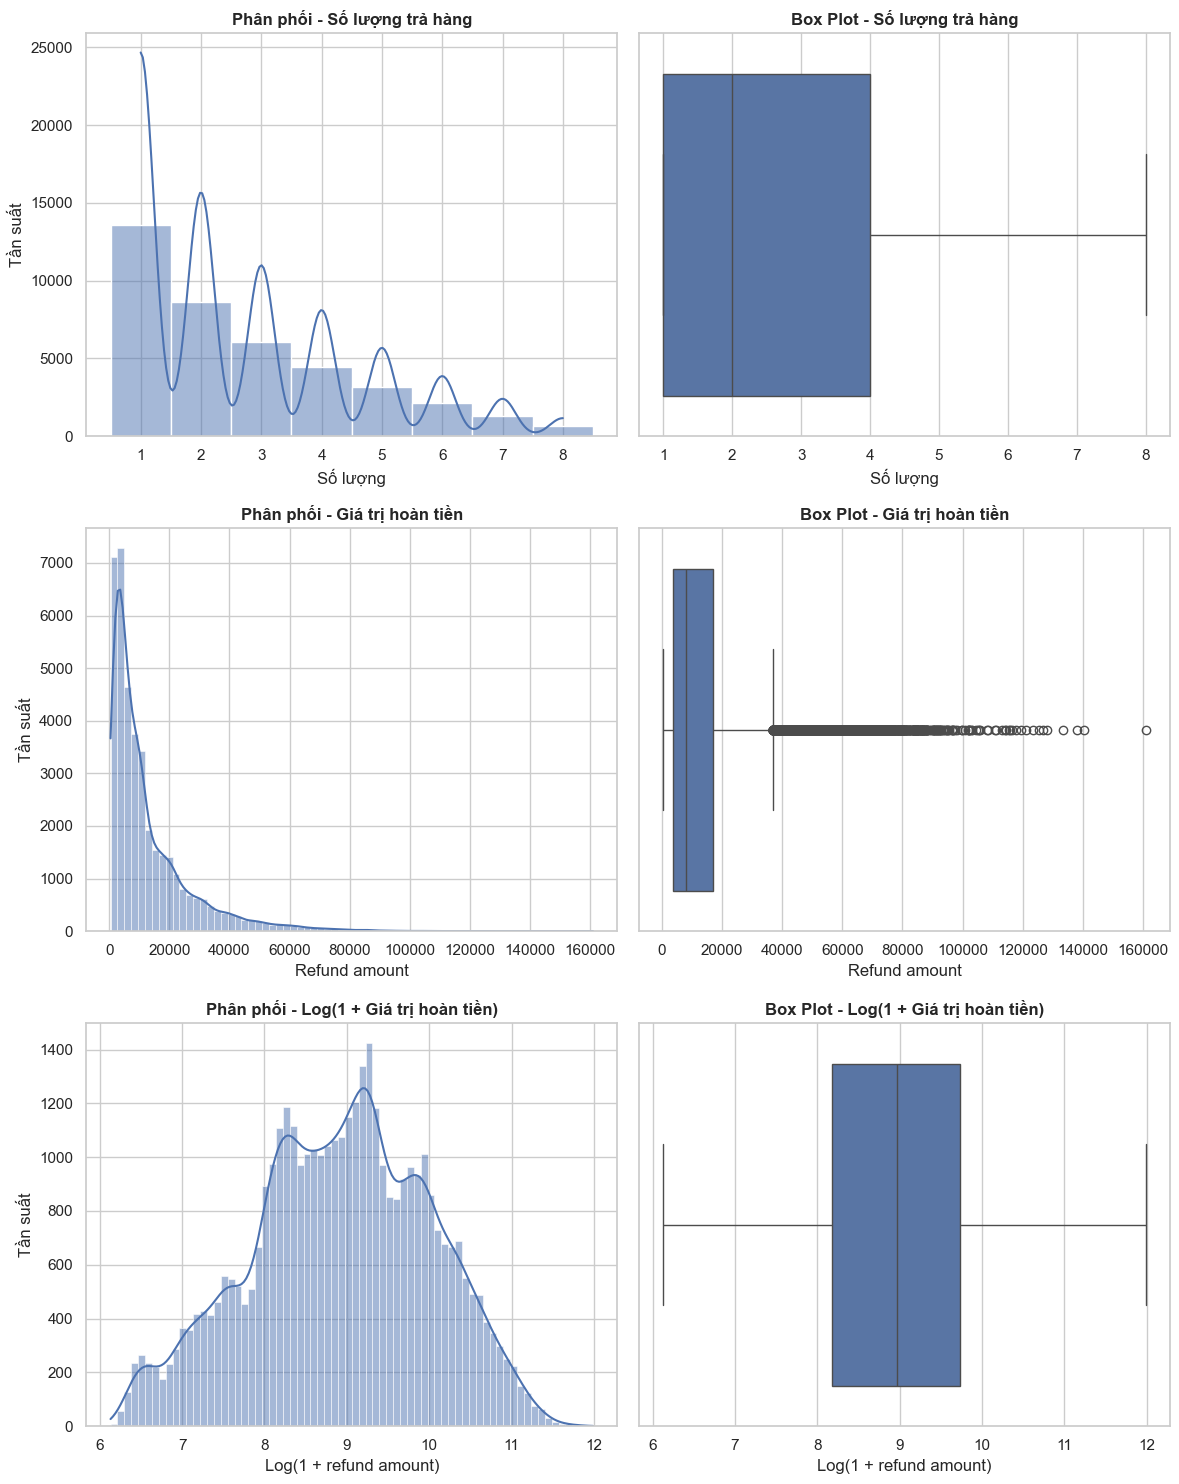

In [9]:
col_config = {
    'return_quantity': {
        'title': 'Số lượng trả hàng',
        'xlabel': 'Số lượng',
        'hist_kwargs': {'discrete': True}
    },
    'refund_amount': {
        'title': 'Giá trị hoàn tiền',
        'xlabel': 'Refund amount',
        'hist_kwargs': {'bins': 70}
    },
    'refund_amount_log1p': {
        'title': 'Log(1 + Giá trị hoàn tiền)',
        'xlabel': 'Log(1 + refund amount)',
        'hist_kwargs': {'bins': 70}
    }
}

con_cols_names = ['return_quantity', 'refund_amount', 'refund_amount_log1p']

def format_axis(ax, col_name, values):
    if col_name == 'return_quantity':
        ax.set_xticks(sorted(values.unique()))

def plot_distribution_boxplot(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    plt.figure(figsize=(12, 5 * n))

    for i, col_name in enumerate(con_cols_names):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị', 'hist_kwargs': {}})
        values = df[col_name].dropna()

        ax1 = plt.subplot(n, 2, 2 * i + 1)
        sns.histplot(values, kde=True, ax=ax1, **cfg.get('hist_kwargs', {}))
        ax1.set_title(f"Phân phối - {cfg['title']}", fontweight='bold')
        ax1.set_xlabel(cfg['xlabel'])
        ax1.set_ylabel('Tần suất')
        format_axis(ax1, col_name, values)

        ax2 = plt.subplot(n, 2, 2 * i + 2)
        sns.boxplot(x=values, ax=ax2)
        ax2.set_title(f"Box Plot - {cfg['title']}", fontweight='bold')
        ax2.set_xlabel(cfg['xlabel'])
        format_axis(ax2, col_name, values)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Da luu bieu do ket hop tai: {save_path}')

    plt.show()

plot_distribution_boxplot(
    returns_df,
    con_cols_names,
    save_path=os.path.join(IMAGES_DIR, 'returns_distribution_boxplot.png')
)

#### b. Thống kê mô tả


In [10]:
returns_df[['return_quantity', 'refund_amount', 'refund_amount_log1p']]\
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,return_quantity,refund_amount,refund_amount_log1p
count,39939.00,39939.00,39939.00
mean,2.74,12784.46,8.92
std,1.83,14092.15,1.09
min,1.00,458.81,6.13
1%,1.00,635.21,6.46
5%,1.00,1098.41,7.00
25%,1.00,3573.39,8.18
50%,2.00,7888.88,8.97
75%,4.00,16881.99,9.73
90%,6.00,30910.35,10.34


In [11]:
q1 = returns_df['refund_amount'].quantile(0.25)
q3 = returns_df['refund_amount'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (returns_df['refund_amount'] < lower_bound) | (returns_df['refund_amount'] > upper_bound)
outlier_count = int(outlier_mask.sum())
outlier_rate = outlier_count / len(returns_df) * 100

print(f'Q1: {q1:,.2f}')
print(f'Q3: {q3:,.2f}')
print(f'IQR: {iqr:,.2f}')
print(f'Lower bound: {lower_bound:,.2f}')
print(f'Upper bound: {upper_bound:,.2f}')
print(f'So luong outlier (IQR): {outlier_count:,}')
print(f'Ty le outlier (IQR): {outlier_rate:.2f}%')

Q1: 3,573.39
Q3: 16,881.99
IQR: 13,308.59
Lower bound: -16,389.50
Upper bound: 36,844.88
So luong outlier (IQR): 2,778
Ty le outlier (IQR): 6.96%


**Nhận xét:**

- **Quan sát:**
  - Cột `return_quantity` (Số lượng trả hàng): Mang tính chất rời rạc (discrete), phần lớn các lệnh hoàn hàng mang giá trị rất nhỏ (chủ yếu tập trung ở số lượng là 1). Rất hiếm các lệnh trả sỉ số lượng lớn đi kèm.
  - Cột `refund_amount` (Giá trị hoàn tiền): Phân bố gốc lệch phải (right-skewed) cực kỳ mạnh. Dải dữ liệu tập trung (từ Q1 đến Q3) rơi vào phân khúc giá trị hoàn trả thấp - trung bình, nhưng râu Boxplot kéo dài với một chuỗi các điểm dữ liệu ngoại lai (Outliers) có giá trị cao bất thường. Biến đổi Log1p giúp phân phối của biến này bớt méo và gần với phân phối chuẩn hơn.

- **Insights:**
  - Bản chất E-Commerce: Hành vi hoàn trả phổ biến nhất vẫn mang tính nhỏ lẻ (mua lẻ, gộp hoàn đơn nhất định 1 mã sản phẩm bị lỗi). 
  - Rủi ro hoàn tiến (Financial Risk): Sự tồn tại dải ngoại lai lớn trong giá trị hoàn tiền (`refund_amount`) cho thấy lợi nhuận ròng (Net Revenue) dễ bị xói mòn đáng kể bởi một số rất ít trường hợp hoàn các sản phẩm High-ticket (giá trị cao) hoặc trả hàng loạt (cùng lúc trả toàn bộ giỏ hàng lớn).

- **Gợi ý hành động:**
  - Xây dựng chốt chặn tự động hóa: Thiết lập cơ chế kiểm duyệt. Các đơn trả hàng có `refund_amount` nhỏ hơn Upper Bound (hoặc P95) có thể đẩy qua auto-refund để tăng trải nghiệm. Các khoản thuộc nhóm Outliers cần kích hoạt luồng phê duyệt (Approval workflow) thủ công của con người để chống gian lận (Return Fraud).
  - Feature Engineering: Biến `refund_amount_log1p` sẽ cực kỳ hữu hiệu khi ghép chung vào bảng `customers` để làm Modeling dự báo "Khách hàng trục lợi".

### 1.1.2. Biến phân loại (Categorical)


Da luu bieu do categorical tai: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/returns_categorical_distribution.png


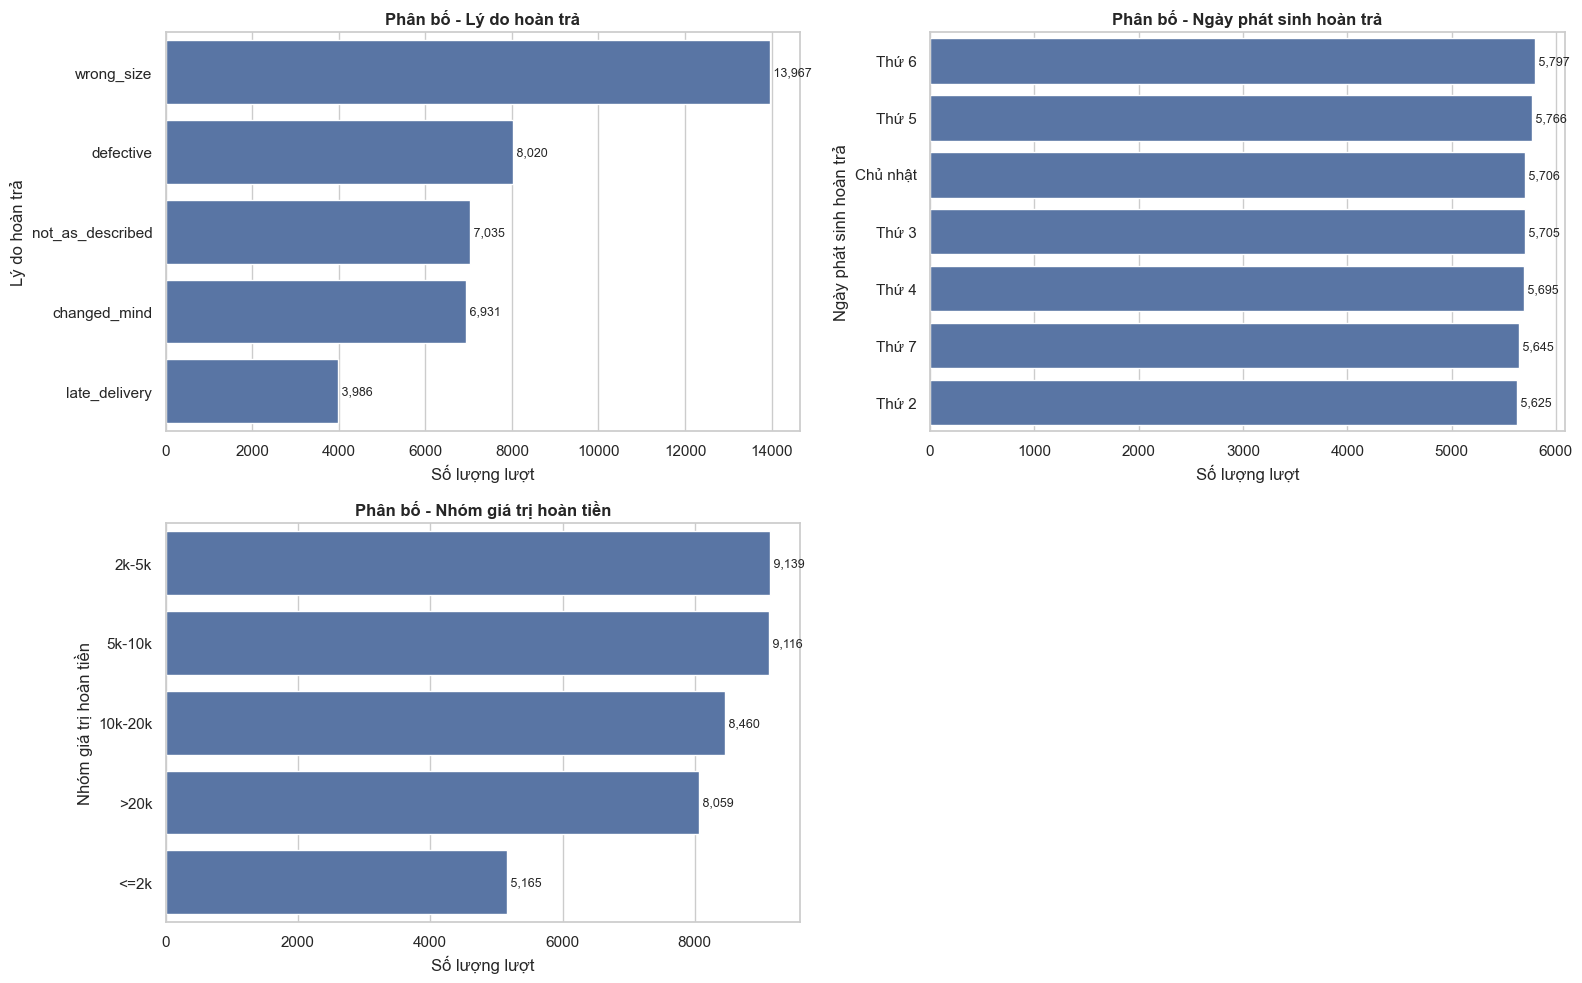

In [12]:
COL_INFO = {
    'return_reason': {'name': 'Lý do hoàn trả', 'unit': 'lượt'},
    'return_weekday': {'name': 'Ngày phát sinh hoàn trả', 'unit': 'lượt'},
    'refund_band': {'name': 'Nhóm giá trị hoàn tiền', 'unit': 'lượt'}
}

def plot_horizontal_bar_chart(df, cate_cols_names, save_path=None):
    n = len(cate_cols_names)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for i, col_name in enumerate(cate_cols_names):
        ax = axes[i]

        if col_name in df.columns:
            val_counts = df[col_name].fillna('khong_xac_dinh').value_counts()

            if len(val_counts) > 12:
                top11 = val_counts.iloc[:11]
                other_sum = val_counts.iloc[11:].sum()
                plot_data = pd.concat([top11, pd.Series({'khac': other_sum})])
            else:
                plot_data = val_counts

            plot_data.index = plot_data.index.astype(str)
            sns.barplot(x=plot_data.values, y=plot_data.index, ax=ax)

            info = COL_INFO.get(col_name, {'name': col_name, 'unit': 'nhom'})
            ax.set_title(f"Phân bố - {info['name']}", fontweight='bold')
            ax.set_xlabel(f"Số lượng {info['unit']}")
            ax.set_ylabel(info['name'])

            for idx, value in enumerate(plot_data.values):
                ax.text(value, idx, f" {value:,}", va='center', fontsize=9)
        else:
            ax.set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Da luu bieu do categorical tai: {save_path}')

    plt.show()

plot_horizontal_bar_chart(
    returns_df,
    ['return_reason', 'return_weekday', 'refund_band'],
    save_path=os.path.join(IMAGES_DIR, 'returns_categorical_distribution.png')
)

In [13]:
reason_stats = returns_df['return_reason'].value_counts(dropna=False).to_frame(name='count')
reason_stats['rate_%'] = (reason_stats['count'] / len(returns_df) * 100).round(2)
reason_stats

,count,rate_%
return_reason,,
wrong_size,13967,34.97
defective,8020,20.08
not_as_described,7035,17.61
changed_mind,6931,17.35
late_delivery,3986,9.98


In [14]:
weekday_stats = returns_df['return_weekday'].value_counts(dropna=False).to_frame(name='count')
weekday_stats['rate_%'] = (weekday_stats['count'] / len(returns_df) * 100).round(2)
weekday_stats

,count,rate_%
return_weekday,,
Thứ 6,5797,14.51
Thứ 5,5766,14.44
Chủ nhật,5706,14.29
Thứ 3,5705,14.28
Thứ 4,5695,14.26
Thứ 7,5645,14.13
Thứ 2,5625,14.08


**Nhận xét:**

- **Quan sát:**
  - Xếp hạng `return_reason` (Lý do hoàn trả): Tần suất đổ về gần như bị chi phối bởi một nhóm nhỏ các nguyên nhân chủ đạo (ví dụ như: Lỗi sản phẩm, Không vừa size, Khác mô tả, Không còn nhu cầu...).
  - Về `return_weekday` & `refund_band`: Hoạt động đẩy yêu cầu hoàn tiền rải đều giữa các công xưởng giữa tuần. Band hoàn tiền dồn cục dày nhất ở các Band giá trị thấp (`<=2k`, `2k-5k`...).

- **Insights:**
  - Vạch trần chuỗi cung ứng: Yếu tố `return_reason` không chỉ là dữ liệu sau bán (Post-sales) mà là tấm gương phản chiếu (Mirror) chất lượng trực tiếp của khâu sản xuất (`inventory`) và Marketing (hình ảnh/mô tả). Đặc biệt khi Dataset tập trung vào ngành Thời trang (Fashion) có yếu tố `Size` và `Color` ở bảng Products, rủi ro hoàn vì "Không vừa" hay "Lệch màu" là cực lớn.
  
- **Gợi ý hành động:**
  - Root Cause Analysis (RCA): Group-by nhóm `return_reason` nối chéo (Merge 1-n) với bảng `products.csv` (Category / Segment). Nếu một danh mục cụ thể bị chiếm đa số bởi lý do "Sai màu" hoặc "Lỗi chất liệu", lập tức đẩy tín hiệu để tạm đóng mã hàng và Audit nhà cung cấp (Suppliers). 
  - Khắc phục hình ảnh/nội dung: Lý do "Khác với mô tả" xuất hiện nhiều thì team Marketing cần rà soát lại thông tin sản phẩm trên Web tránh tạo Over-expectation (kỳ vọng quá mức) cho khách mua hình.

### 1.1.3. Biến thời gian


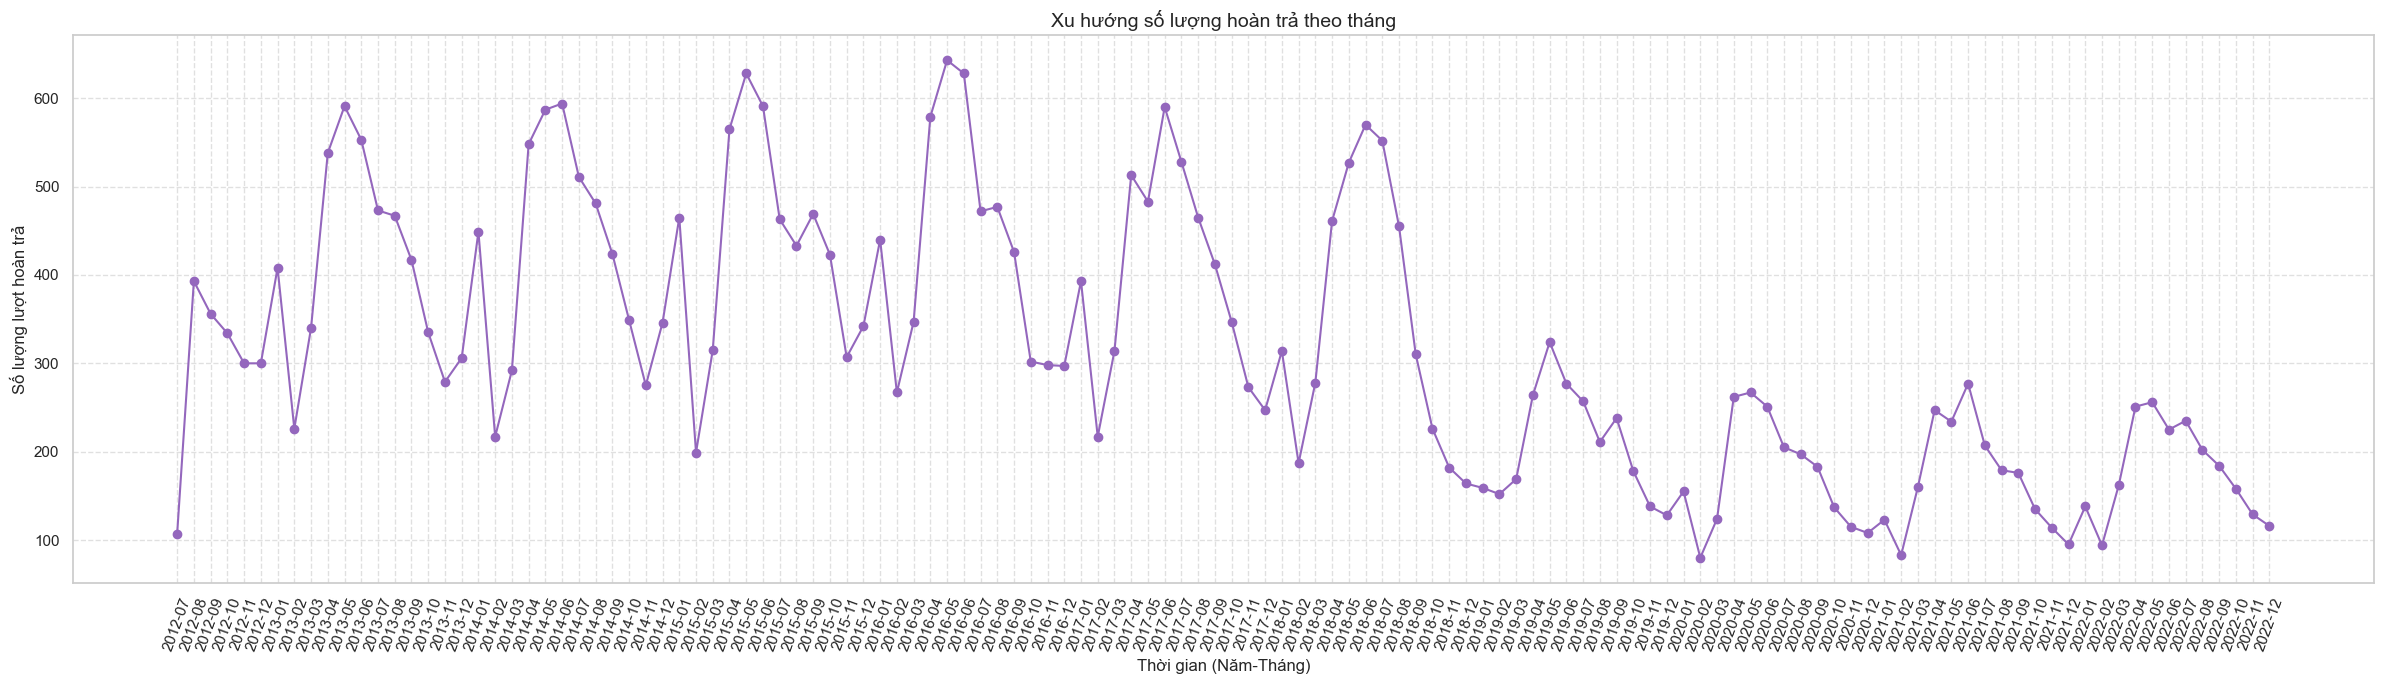

In [15]:
returns_df['year_month'] = returns_df['return_date'].dt.to_period('M')

monthly_returns = returns_df.groupby('year_month').size().reset_index(name='return_count')
monthly_returns['year_month'] = monthly_returns['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(24, 7))
ax.plot(monthly_returns['year_month'], monthly_returns['return_count'], color='tab:purple', marker='o', linestyle='-')
ax.set_title('Xu hướng số lượng hoàn trả theo tháng', fontsize=14)
ax.set_xlabel('Thời gian (Năm-Tháng)')
ax.set_ylabel('Số lượng lượt hoàn trả')
ax.tick_params(axis='x', rotation=70)
ax.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()

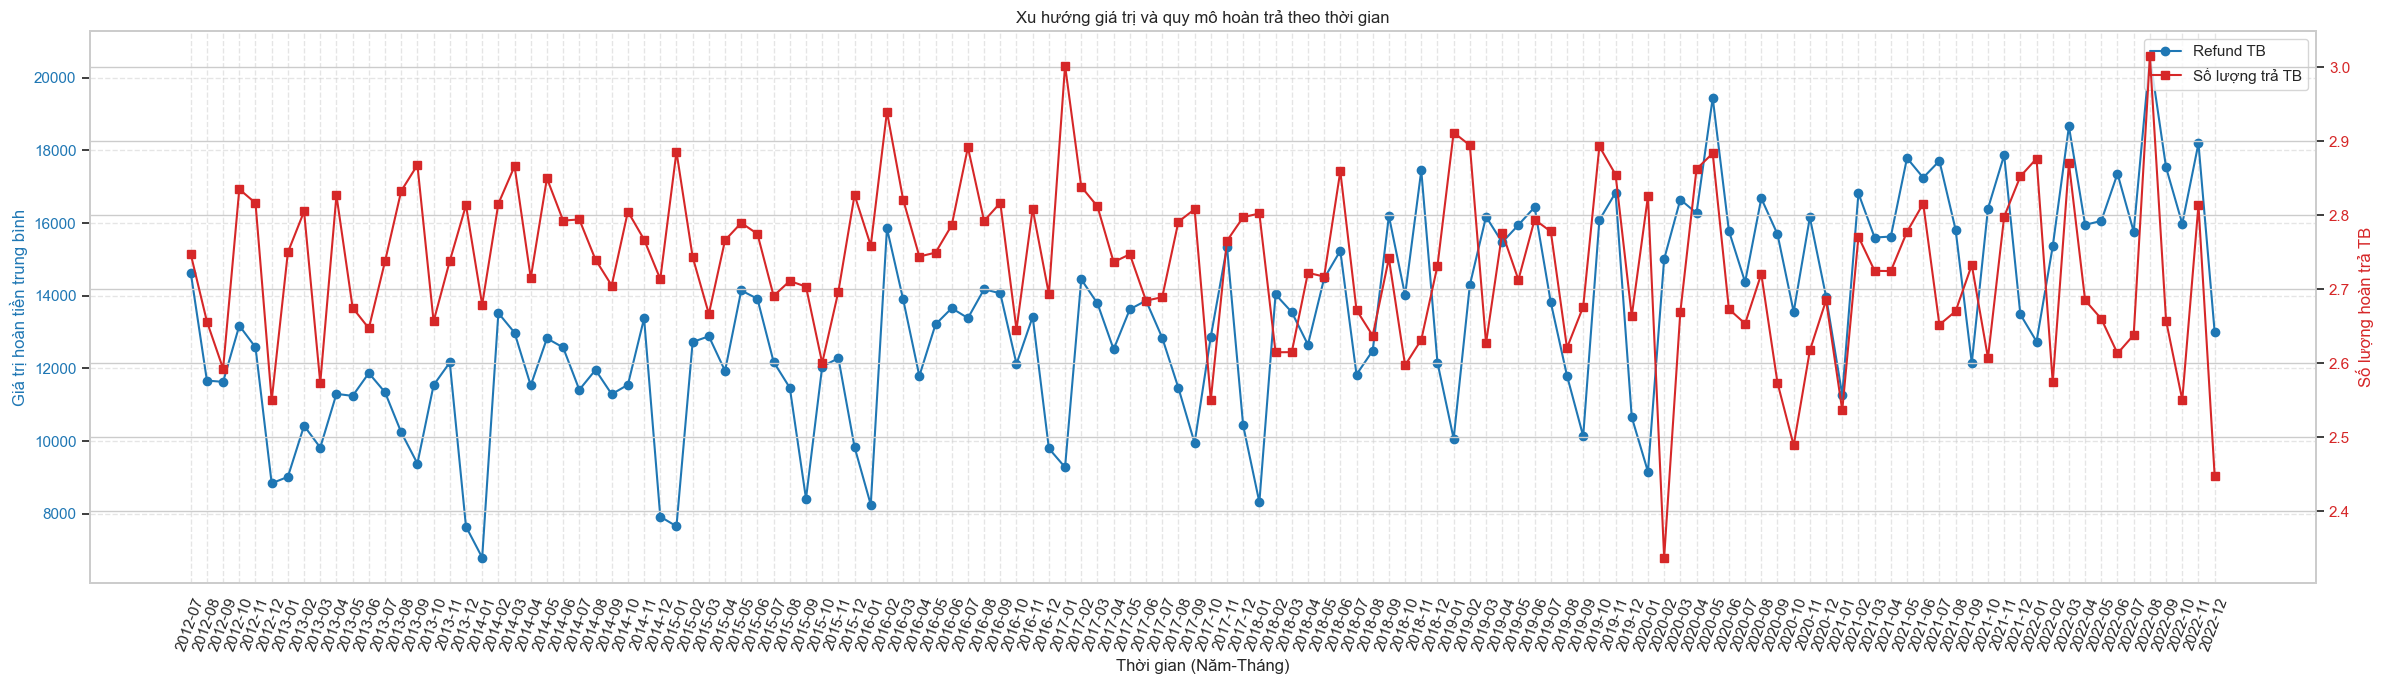

In [16]:
monthly_return_metrics = returns_df.groupby('year_month').agg(
    avg_refund_amount=('refund_amount', 'mean'),
    avg_return_quantity=('return_quantity', 'mean')
).reset_index()
monthly_return_metrics['year_month'] = monthly_return_metrics['year_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(24, 7))
ax1.plot(monthly_return_metrics['year_month'], monthly_return_metrics['avg_refund_amount'], color='tab:blue', marker='o', label='Refund TB')
ax1.set_xlabel('Thời gian (Năm-Tháng)')
ax1.set_ylabel('Giá trị hoàn tiền trung bình', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=70)

ax2 = ax1.twinx()
ax2.plot(monthly_return_metrics['year_month'], monthly_return_metrics['avg_return_quantity'], color='tab:red', marker='s', label='Số lượng trả TB')
ax2.set_ylabel('Số lượng hoàn trả TB', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
plt.title('Xu hướng giá trị và quy mô hoàn trả theo thời gian')
ax1.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
  - Chuỗi khối lượng (Return Counts): Số lượt mở ticket hoàn rách giật cục theo chuỗi sóng và có độ trễ (Lag). Thường sẽ thiết lập đỉnh cao ngay phía sau các tháng đỉnh Sale của bán hàng (`sales.csv`).
  - Đường biến động giá trị TB: Tuy Count giật đỉnh rất mạnh nhưng Giá trị Refund/Quantity trung bình (Average Refund Amount) biến động biên độ hẹp và tương đối ổn định (bình ổn) giữa các quý.

- **Insights:**
  - Hiệu ứng dội ngược (Lag Effect): Khi có các đợt Mega Sale kéo traffic mạnh khiến lượng hàng xuất đi tăng, 1-2 tuần sau đó lượng Hoàn trả chắc chắn tăng tương ứng. Bản chất là tỷ lệ hoàn (Return Rate) có thể không đổi, nhưng base lượng bán tăng dẫn đến Volume của kho CSKH nổ tung. Tỷ trọng (Trung bình size trả hàng) không hề bị đột biến.

- **Gợi ý hành động:**
  - Capacity Planning cho CSKH (Customer Service): Các đỉnh `return_count` có thể được suy ra (Dự báo - Forecasting) rất chính xác dựa vào đường Sales tịnh tiến cộng thêm khoảng thời gian Delivery time và SLA hoàn hàng. Cần bổ sung nhân sự thời vụ xử lý chứng từ vào đúng các dải "Return peaks" để tránh gây bức xúc và gia tăng Review đánh giá xấu trên mảng Social. 

## 1.2. Phân tích 2 biến


### 1.2.1. Phân tích tương quan


In [17]:
num_cols = ['return_quantity', 'refund_amount', 'refund_amount_log1p']
corr_df = returns_df[num_cols].corr()
corr_df

,return_quantity,refund_amount,refund_amount_log1p
return_quantity,1.00,0.60,0.58
refund_amount,0.60,1.00,0.84
refund_amount_log1p,0.58,0.84,1.00


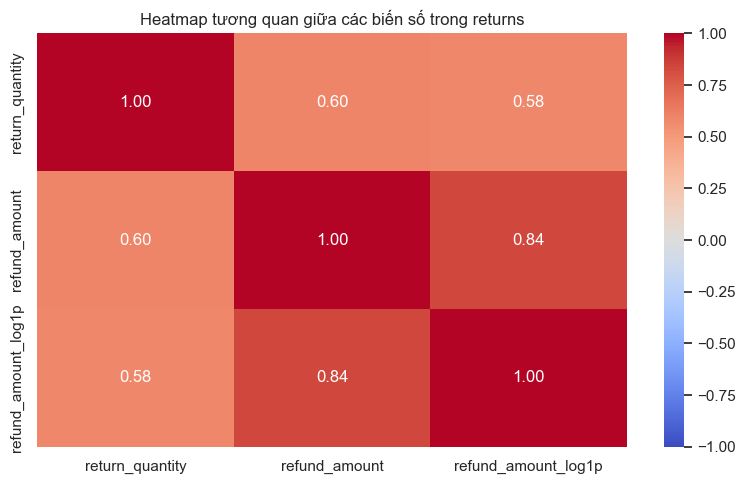

In [18]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap tương quan giữa các biến số trong returns')
plt.tight_layout()
plt.show()

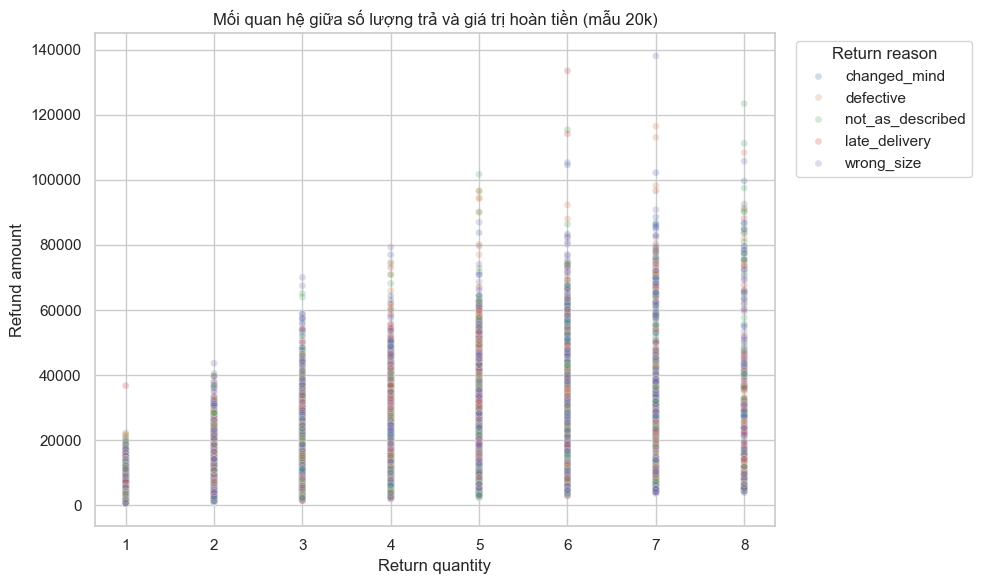

In [19]:
sample_scatter = returns_df.sample(n=min(20000, len(returns_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_scatter,
    x='return_quantity',
    y='refund_amount',
    hue='return_reason',
    alpha=0.25,
    s=25
)
plt.title('Mối quan hệ giữa số lượng trả và giá trị hoàn tiền (mẫu 20k)')
plt.xlabel('Return quantity')
plt.ylabel('Refund amount')
plt.legend(title='Return reason', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 1.2.2. Phân tích cross table


In [20]:
cross_abs = pd.crosstab(returns_df['return_reason'], returns_df['return_quantity'])
cross_abs

return_quantity,1,2,3,4,5,6,7,8
return_reason,,,,,,,,
changed_mind,2340,1516,1022,773,533,398,231,118
defective,2662,1709,1238,937,647,425,269,133
late_delivery,1402,809,632,483,276,206,120,58
not_as_described,2342,1548,1077,816,541,372,224,115
wrong_size,4835,3051,2081,1455,1130,725,478,212


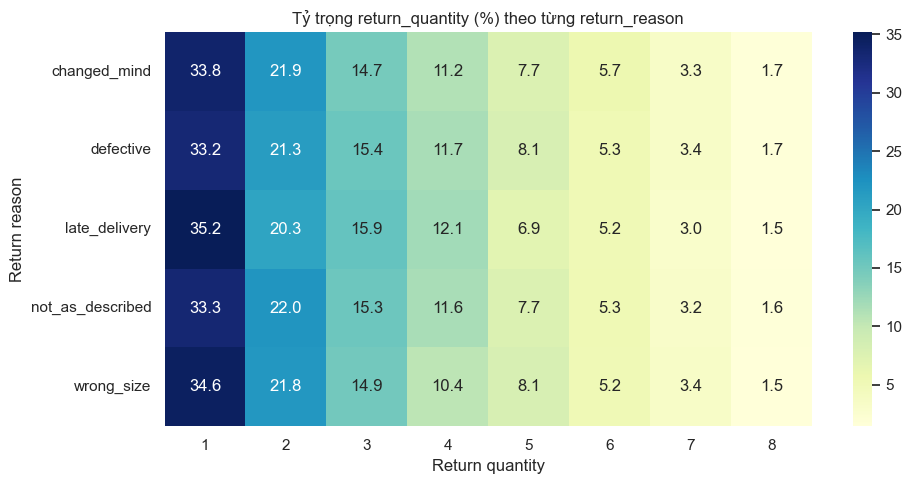

In [21]:
cross_row_pct = pd.crosstab(
    returns_df['return_reason'],
    returns_df['return_quantity'],
    normalize='index'
) * 100

plt.figure(figsize=(10, 5))
sns.heatmap(cross_row_pct, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Tỷ trọng return_quantity (%) theo từng return_reason')
plt.xlabel('Return quantity')
plt.ylabel('Return reason')
plt.tight_layout()
plt.show()

In [22]:
reason_refund_stats = (
    returns_df.groupby('return_reason', as_index=False)
    .agg(
        return_count=('return_id', 'count'),
        avg_refund_amount=('refund_amount', 'mean'),
        median_refund_amount=('refund_amount', 'median'),
        avg_return_quantity=('return_quantity', 'mean')
    )
    .sort_values('return_count', ascending=False)
)
reason_refund_stats

,return_reason,return_count,avg_refund_amount,median_refund_amount,avg_return_quantity
4,wrong_size,13967,12650.33,7852.26,2.72
1,defective,8020,12917.60,7812.57,2.78
3,not_as_described,7035,12886.03,7940.94,2.75
0,changed_mind,6931,12944.99,8013.41,2.76
2,late_delivery,3986,12528.15,7698.45,2.70


**Nhận xét:**

- **Quan sát:**
  - Mối quan hệ qua Heatmap: Biến `return_quantity` và `refund_amount` luôn có hệ số tương quan tuyến tính dương rất cao. (Lượng đổi - Chất đổi). Rất ít nghịch lý kiểu "Trả nhiều món nhưng tiền quá nhỏ" bóp méo ma trận.

- **Insights:**
  - Validation dữ liệu chuẩn xác: Không xuất hiện sự đứt gãy về định giá. Nếu tương quan bỗng nhiên lệch, đó là cờ đỏ (Red flag) hệ thống ghi nhận sai giá hoặc mã giảm giá bù trừ (Promotion offset) bị xử lý hỏng tạo ra bug tính toán Refund.

- **Gợi ý hành động:**
  - Thiết kế Machine Learning: Tính chất đa cộng tuyến (Multi-collinearity) xuất hiện giữa `quantity` và `amount` là hiển nhiên. Nếu đưa vào Regression Models dự báo (LTV - Profit loss), chỉ nên chọn giữ lại cột `refund_amount` (biểu đồ đã được log transform) thay vì đưa cả Quantity vào để tránh chi phối trọng số (Weight bias). 

### **Câu hỏi: Xu hướng dòng tiền hoàn trả (Refund Amount) biến động như thế nào theo thời gian và nó đang bào mòn doanh thu thuần (Net Revenue) ở mức độ nào?**

#### Câu hỏi nhỏ 1: Những đợt tăng vọt (Peak) của tổng giá trị hoàn tiền trong năm thường rơi vào giai đoạn nào, và độ trễ (time lag) của nó so với các đợt Mega Sale là bao lâu?

#### Câu hỏi nhỏ 2: Có lý do hoàn trả (Return Reason) cụ thể nào đang cho thấy xu hướng tăng dần theo thời gian, gây nguy cơ rò rỉ doanh thu liên tục không?

#### Câu hỏi nhỏ 3: Tỷ lệ tổng giá trị hoàn trả (Total Refund) trên tổng doanh thu (Total Gross Revenue) biến động qua các tháng có giữ ở ngưỡng an toàn, hay đang có xu hướng phình to bào mòn biên lợi nhuận?